# Para esta Tarea

Generar un archivo tipo Notebook de Python que contenga el código fuente de varios ejercicios aplicados a los conceptos vistos:

- Importación de datos de stocks del ejercicio anterior.
- Generación de modelo de series de tiempo aplicado a los datos importados usando el modelo de Reversión a la Media, y además el de Movimiento Browniano.
- Modelo autorregresivo y de moving average.
- Ejercicio de predicción de modelos.
- Visualización simple de Series de Tiempo.

# Desarrollo

## Importacion de librerias

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Librerias para uso esdistico y de series de tiempo

In [ ]:
!pip install chart_studio
import chart_studio.plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff
import statsmodels.api as sm
from numpy.random import normal, seed
from scipy.stats import norm
import math
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess

---

## EDA

In [4]:
df = pd.read_csv('../../../Archivos-Analisis/files-tarea-m47/GOOG.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,2004-8-19,2.490664,2.591785,2.390042,2.499133,2.480529,897427216,NaN,NaN
1,2004-8-20,2.515820,2.716817,2.503118,2.697639,2.677557,458857488,NaN,NaN
2,2004-8-23,2.758411,2.826406,2.716070,2.724787,2.704503,366857939,NaN,NaN
3,2004-8-24,2.770615,2.779581,2.579581,2.611960,2.592516,306396159,NaN,NaN
4,2004-8-25,2.614201,2.689918,2.587302,2.640104,2.620450,184645512,NaN,NaN
...,...,...,...,...,...,...,...,...,...
5383,2026-1-12,326.500000,334.440002,325.510010,332.730011,332.730011,23893800,NaN,NaN
5384,2026-1-13,335.279999,341.200012,334.350006,336.429993,336.429993,24616700,NaN,NaN
5385,2026-1-14,334.984985,337.029999,331.140015,336.309998,336.309998,17839300,NaN,NaN
5386,2026-1-15,338.054993,338.130005,331.290009,333.160004,333.160004,16424900,NaN,NaN


In [5]:
df.dtypes

Date             object
Open            float64
High            float64
Low             float64
Close           float64
Adj Close       float64
Volume            int64
Dividends       float64
Stock Splits     object
dtype: object

In [6]:
df.isnull().sum()

Date               0
Open               0
High               0
Low                0
Close              0
Adj Close          0
Volume             0
Dividends       5381
Stock Splits    5385
dtype: int64

In [16]:
df.shape

(5388, 7)

Insights:
- Las columnas Dividends y Stock Splits, no aportaran mucho al analisis por lo que se sugiere su eliminacion
- Ademas de portar con pocos datos para su uso

### Eliminacion de las columnas 

In [8]:
df.drop(['Dividends', 'Stock Splits'], axis=1, inplace=True)
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-8-19,2.490664,2.591785,2.390042,2.499133,2.480529,897427216
1,2004-8-20,2.515820,2.716817,2.503118,2.697639,2.677557,458857488
2,2004-8-23,2.758411,2.826406,2.716070,2.724787,2.704503,366857939
3,2004-8-24,2.770615,2.779581,2.579581,2.611960,2.592516,306396159
4,2004-8-25,2.614201,2.689918,2.587302,2.640104,2.620450,184645512
...,...,...,...,...,...,...,...
5383,2026-1-12,326.500000,334.440002,325.510010,332.730011,332.730011,23893800
5384,2026-1-13,335.279999,341.200012,334.350006,336.429993,336.429993,24616700
5385,2026-1-14,334.984985,337.029999,331.140015,336.309998,336.309998,17839300
5386,2026-1-15,338.054993,338.130005,331.290009,333.160004,333.160004,16424900


In [12]:
# Cambiamos el formato de pandas para visualizar los datos de una forma mas amigable
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [14]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Open,5388.00,56.06,59.34,2.47,13.35,29.16,76.27,338.05
High,5388.00,56.67,60.03,2.53,13.45,29.29,78.08,341.20
Low,5388.00,55.48,58.69,2.39,13.20,28.91,75.65,334.35
Close,5388.00,56.08,59.37,2.49,13.33,29.10,76.16,336.43
Adj Close,5388.00,55.74,59.14,2.47,13.23,28.88,75.59,336.43
Volume,5388.00,109351649.03,146530608.29,158434.00,25731500.00,47752171.00,132646334.25,1650832619.00


---

## Reversion a la Media

In [40]:
def mod_vasicek(r0, k, theta, sigma, T=1, N=10, seed=777):
    """ Simula la evolucion de las tasas de interes segun el modelo de Vasicek
    r0: tasa inicial
    k: velocidad de reversion
    theta: tasa media a largo plazo
    sigma: volatilidad
    T: horizonte temporal (en años)
    N: numero de pasos
    seed: semilla para numeros aleatorios
    """
    np.random.seed(seed)
    dt = T / N
    rates = [r0]
    for _ in range(N):
        dr = k * (theta - rates[-1]) * dt + sigma * np.random.normal()
        rates.append(rates[-1] + dr)
    return range(N + 1), rates

In [43]:
# Parametros de la serie de tiempo
r0 = 0.1875
k = 0.2
theta = 0.04
sigma =0.012
T = 10
seed = np.random.randint(100, 900)
N = 1000

# Llamamos a la funcion Vasicek
x, y = mod_vasicek(r0, k, theta, sigma, T, N, seed)

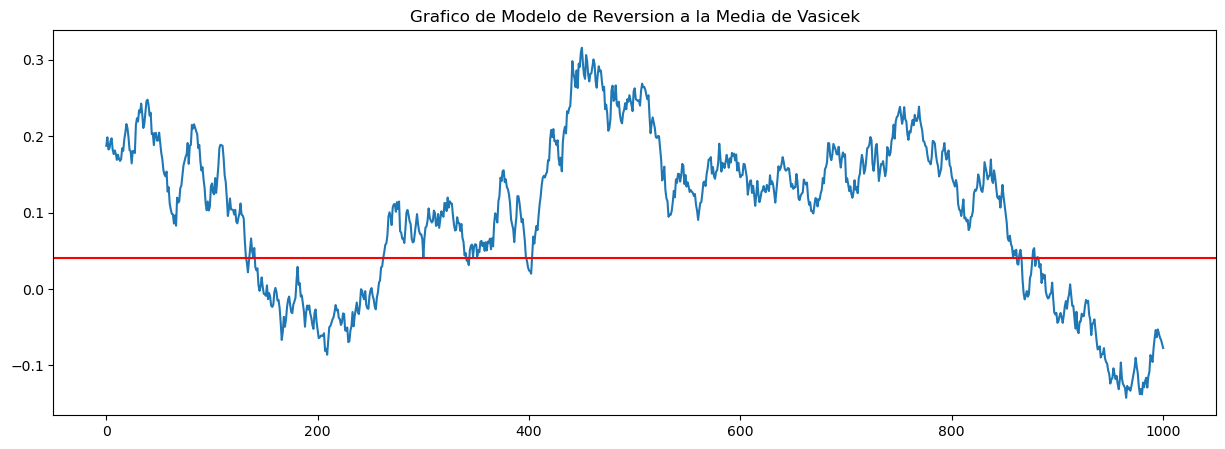

In [44]:
# Generamos el grafico del modelo
plt.figure(figsize=(15, 5))
plt.plot(x, y)
plt.title('Grafico de Modelo de Reversion a la Media de Vasicek')
plt.axhline(theta, color='red')
plt.show()

---

## Movimiento Browniano

In [45]:
# Parametros del proceso
delta = 0.25
dt = 0.1

# Punto de inicio
x = 0.0
xinit = 0

# Numero de interaciones
n = 10

# Genera los distintos puntos de la serie
for k in range(n):
    x = x + norm.rvs(scale = delta * dt)
    print(x)

0.016007532760776995
-0.0011536367322172447
0.009745712318396361
-0.013085002231044269
0.002541053075208046
0.020402635790564207
0.08561484899687954
0.040515696961327084
0.04040178100916137
0.04464165504750668


In [46]:
# Numero de trayectorias
ntra = 10

# Numerp de interaciones
n = 20

# Se pueden guardar los caminos diferentes en un DF
res = []

dfres = pd.DataFrame().assign(traj = 0, nsample = 0, sample = 0)

In [47]:
# Genera las trayectorias en un DF (dfres)
for i in range(ntra + 1):
    for k in range(1, n + 1):
        x = x + norm.rvs(scale = delta ** 2 * dt)
        res.append(x)
        df2 = {'traj': i, 'nsample': k, 'sample': x}
        dfres = pd.concat([dfres, pd.DataFrame([df2])], ignore_index = True)
dfres

,traj,nsample,sample
0,0,1,0.04
1,0,2,0.05
2,0,3,0.04
3,0,4,0.04
4,0,5,0.04
...,...,...,...
215,10,16,0.15
216,10,17,0.15
217,10,18,0.16
218,10,19,0.15


In [54]:
# Genera los puntos iniciales
for i in range(ntra + 1):
    df2 = {'traj': i, 'nsample': 0, 'sample': xinit}
    dfres = pd.concat([dfres, pd.DataFrame([df2])], ignore_index=True)

dfres

,traj,nsample,sample
0,0,1,0.04
1,0,2,0.05
2,0,3,0.04
3,0,4,0.04
4,0,5,0.04
...,...,...,...
248,6,0,0.00
249,7,0,0.00
250,8,0,0.00
251,9,0,0.00


C:\Users\RyanHz\AppData\Local\Temp\ipykernel_25860\1408283682.py:2: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




<Axes: xlabel='nsample', ylabel='sample'>

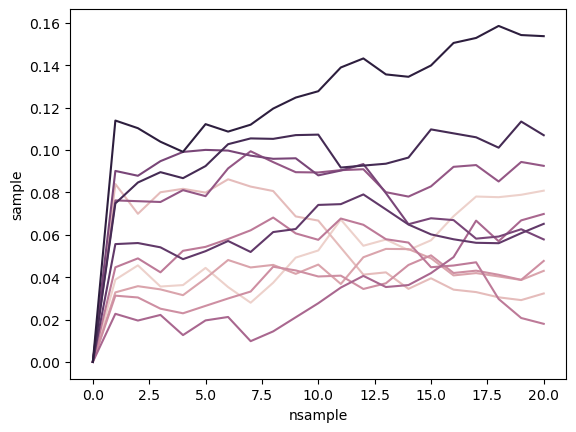

In [55]:
# Plot de la muestras
sns.lineplot(data= dfres, x='nsample', y='sample', legend= None, ci= None, hue='traj')

In [56]:
# Se puieden obtener las trayectorias
pd.pivot_table(dfres, index = ['traj'], columns= ['nsample'])

sample                                               ...            \
nsample     0    1    2    3    4    5    6    7    8    9   ...   11   12   
traj                                                         ...             
0         0.00 0.04 0.05 0.04 0.04 0.04 0.04 0.03 0.04 0.05  ... 0.07 0.05   
1         0.00 0.08 0.07 0.08 0.08 0.08 0.09 0.08 0.08 0.07  ... 0.05 0.04   
2         0.00 0.03 0.04 0.03 0.03 0.04 0.05 0.04 0.05 0.04  ... 0.04 0.05   
3         0.00 0.03 0.03 0.03 0.02 0.03 0.03 0.03 0.04 0.04  ... 0.04 0.03   
4         0.00 0.04 0.05 0.04 0.05 0.05 0.06 0.06 0.07 0.06  ... 0.07 0.06   
5         0.00 0.02 0.02 0.02 0.01 0.02 0.02 0.01 0.01 0.02  ... 0.04 0.04   
6         0.00 0.08 0.08 0.08 0.08 0.08 0.09 0.10 0.09 0.09  ... 0.09 0.09   
7         0.00 0.09 0.09 0.09 0.10 0.10 0.10 0.10 0.10 0.10  ... 0.09 0.09   
8         0.00 0.06 0.06 0.05 0.05 0.05 0.06 0.05 0.06 0.06  ... 0.07 0.08   
9         0.00 0.07 0.08 0.09 0.09 0.09 0.10 0.11 0.11 0.11  ... 0.09 0.09   
10        0.00 0.11 0.11 0.10 0.10 0.11 0.11 0.11 0.12 0.12  ... 0.14 0.14   

                                                 
nsample   13   14   15   16   17   18   19   20  
traj                                             
0       0.06 0.05 0.06 0.07 0.08 0.08 0.08 0.08  
1       0.04 0.03 0.04 0.03 0.03 0.03 0.03 0.03  
2       0.05 0.05 0.05 0.04 0.04 0.04 0.04 0.04  
3       0.04 0.05 0.05 0.04 0.04 0.04 0.04 0.05  
4       0.06 0.06 0.04 0.05 0.05 0.03 0.02 0.02  
5       0.04 0.04 0.04 0.05 0.07 0.06 0.07 0.07  
6       0.08 0.08 0.08 0.09 0.09 0.09 0.09 0.09  
7       0.08 0.06 0.07 0.07 0.06 0.06 0.06 0.06  
8       0.07 0.06 0.06 0.06 0.06 0.06 0.06 0.07  
9       0.09 0.10 0.11 0.11 0.11 0.10 0.11 0.11  
10      0.14 0.13 0.14 0.15 0.15 0.16 0.15 0.15  

[11 rows x 21 columns]

In [57]:
# Obtenemos las medias de las trayectorias
pd.pivot_table(dfres, columns=['nsample'], aggfunc= 'mean')

nsample,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
sample,0.00,0.06,0.06,0.06,0.06,0.06,0.07,0.07,0.07,0.07,...,0.07,0.07,0.07,0.07,0.07,0.07,0.07,0.07,0.07,0.07
traj,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


---

## Autoregresiva

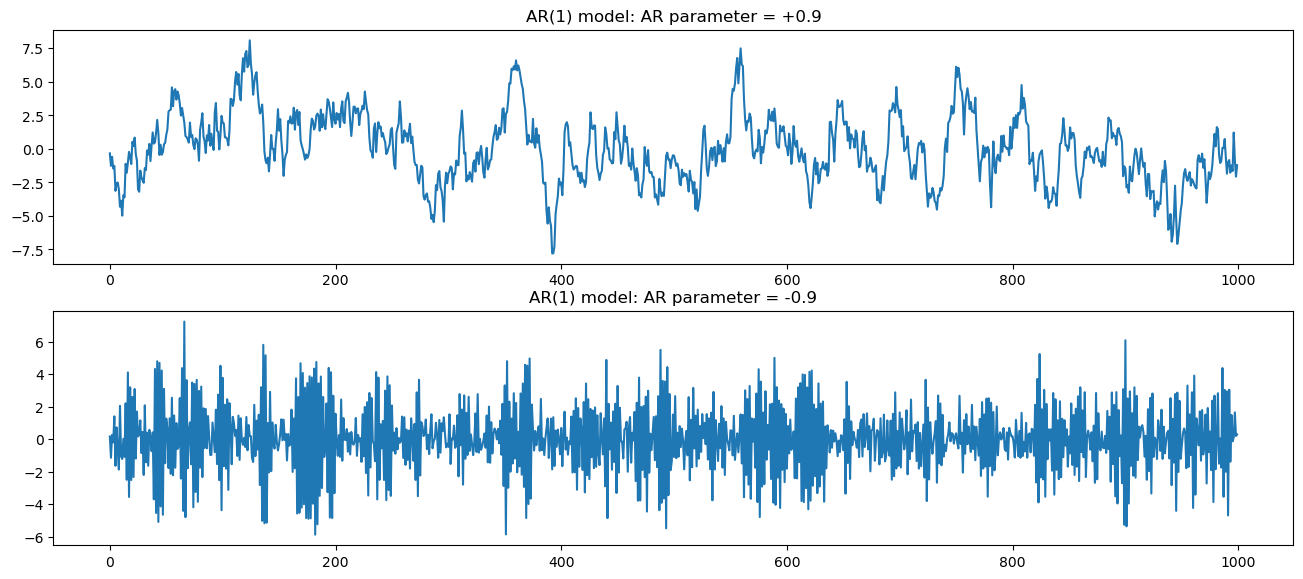

In [62]:
# AR(1), MA(1), model: AR parametro = +0.9
plt.figure(figsize=(16, 14))
plt.subplot(4, 1, 1)

# Se especifican los parametros de AR y MA (AR -0.9)
ar1 = np.array([1, -0.9])
ma1 = np.array([1])
AR1 = ArmaProcess(ar1, ma1)
sim1 = AR1.generate_sample(nsample=1000)
plt.title('AR(1) model: AR parameter = +0.9')
plt.plot(sim1)

# Se especifican los parametros de AR y MA (AR 0.9)
plt.subplot(4, 1, 2)
ar2 = np.array([1, 0.9])
ma2 = np.array([1])
AR2 = ArmaProcess(ar2, ma2)
sim2 = AR2.generate_sample(nsample=1000)
plt.title('AR(1) model: AR parameter = -0.9')
plt.plot(sim2)

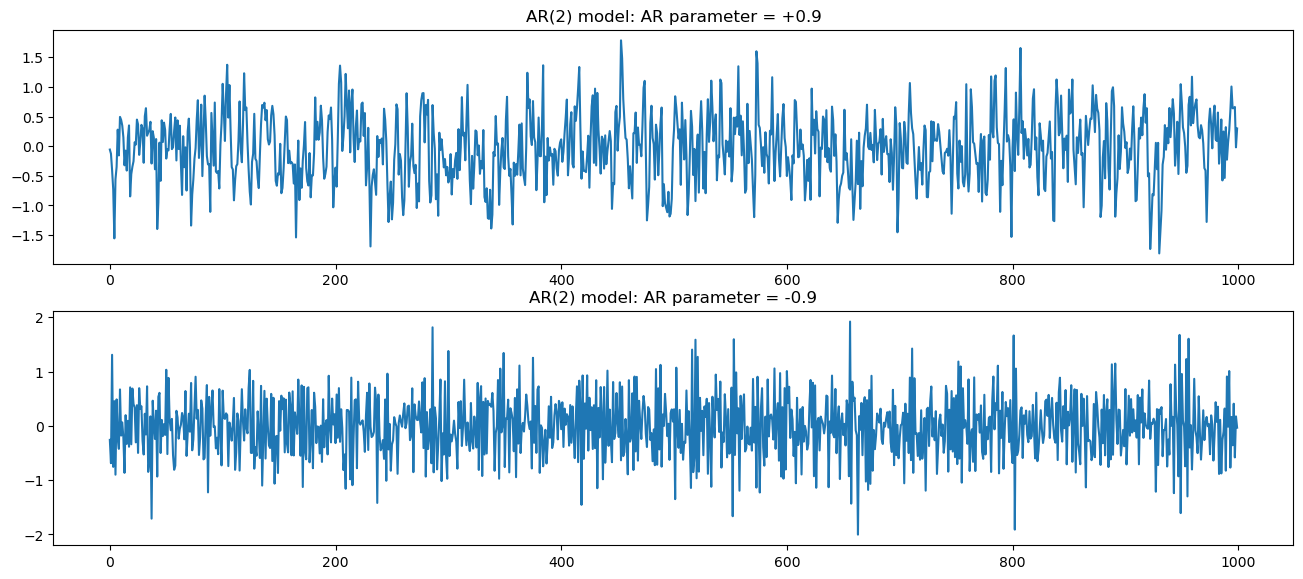

In [63]:
# Generamos la misma serie, pero con AR(2)
# AR(2), MA(1), model: AR parametro = +0.9
plt.figure(figsize=(16, 14))
plt.subplot(4, 1, 3)

# Se especifican los parametros de AR y MA (AR -0.9)
ar3 = np.array([2, -0.9])
ma3 = np.array([1])
AR3 = ArmaProcess(ar3, ma3)
sim3 = AR3.generate_sample(nsample=1000)
plt.title('AR(2) model: AR parameter = +0.9')
plt.plot(sim3)

# Se especifican los parametros de AR y MA (AR 0.9)
plt.subplot(4, 1, 4)
ar4 = np.array([2, 0.9])
ma4 = np.array([1])
AR4 = ArmaProcess(ar4, ma4)
sim4 = AR4.generate_sample(nsample=1000)
plt.title('AR(2) model: AR parameter = -0.9')
plt.plot(sim4)

In [67]:
# Forecasting con AR
# Usamos el model.fit para hacer una prediccion automatica 
model = ARIMA(sim1, order= (1, 0, 0)) # (p,d,q) → aquí es AR(1)
result = model.fit()

In [68]:
print('u={} , o={}'.format(result.params[0], result.params[1]))
print(result.summary())

u=-0.017676894318677555 , o=0.9178501283768149
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1416.417
Date:              lun., 19 ene. 2026   AIC                           2838.834
Time:                        18:36:12   BIC                           2853.558
Sample:                             0   HQIC                          2844.430
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0177      0.385     -0.046      0.963      -0.772       0.736
ar.L1          0.9179      0.012     74.758      0.000       0.894       0.942
sigma

---

## Moving Average

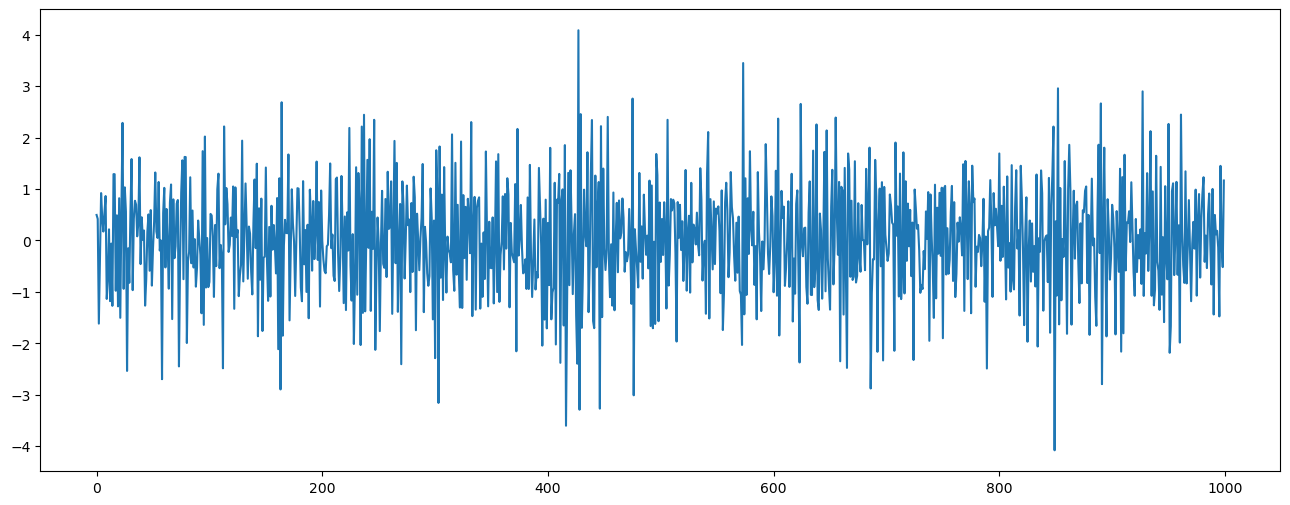

In [69]:
# Generacion de ujna serie tipo MA con 0.5
plt.figure(figsize=(16,6))
ar1 = np.array([1])
ma1 = np.array([1, -0.5])
MA1 = ArmaProcess(ar1, ma1)
sim1 = MA1.generate_sample(nsample=1000)
plt.plot(sim1)

In [70]:
# Forecasting con MA
model = ARIMA(sim1, order=(0, 0, 1)) # (p,d,q) → aquí es MA(1)
result = model.fit()

In [71]:
print('u={} , o={}'.format(result.params[0], result.params[1]))
print(result.summary())

u=0.005646621210727055 , o=-0.5064209606908218
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1399.781
Date:              lun., 19 ene. 2026   AIC                           2805.561
Time:                        18:40:43   BIC                           2820.284
Sample:                             0   HQIC                          2811.157
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0056      0.015      0.368      0.713      -0.024       0.036
ma.L1         -0.5064      0.026    -19.554      0.000      -0.557      -0.456
sigma

In [72]:
# Prediccion para le precio de Google
# Prediccion de las variaciones absolutas
df_google = df.copy()
df_google['Close'].diff().iloc[1:].values

array([ 0.19850588,  0.02714801, -0.11282706, ..., -0.11999512,
       -3.1499939 , -2.82000732], shape=(5387,))

In [74]:
# Se define la serie ARIMA y luego se procede con el modelo fit
model = ARIMA(df_google['Close'].diff().iloc[1:].values, order=(0, 0, 3))
result = model.fit()

In [75]:
print('u={} , o={}'.format(result.params[0], result.params[1]))
print(result.summary())

u=0.06088281928243499 , o=-0.006824627866233101
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5387
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -9832.179
Date:              lun., 19 ene. 2026   AIC                          19674.358
Time:                        18:43:54   BIC                          19707.317
Sample:                             0   HQIC                         19685.866
                               - 5387                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0609      0.020      3.005      0.003       0.021       0.101
ma.L1         -0.0068      0.006     -1.191      0.234      -0.018       0.004
ma.L

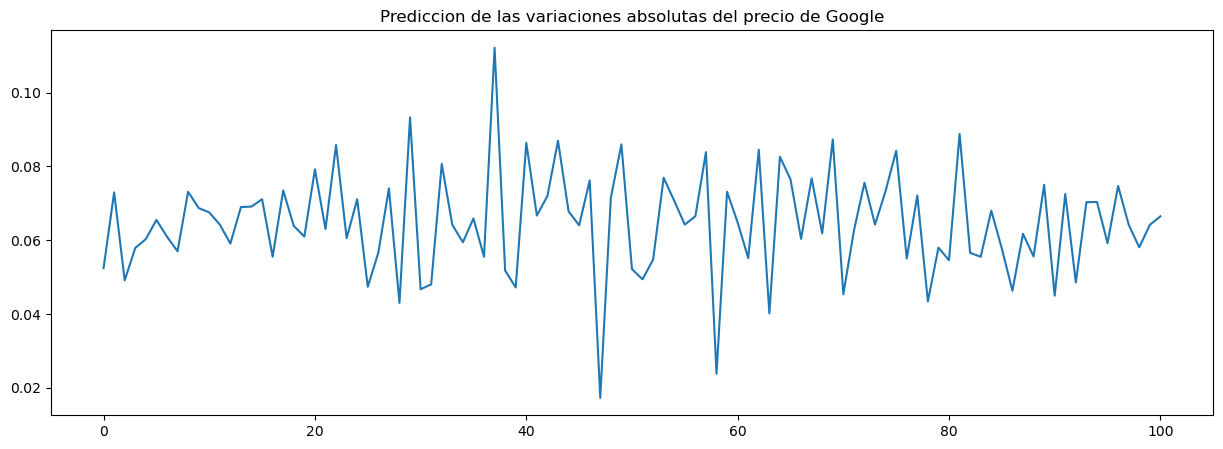

In [77]:
# Obtenemos las predicciones
predictions = result.predict(start=1000, end=1100)

# Plot de las predicciones
plt.figure(figsize=(15, 5))
plt.plot(predictions)
plt.title('Prediccion de las variaciones absolutas del precio de Google')
plt.show()

In [78]:
# Se evalua con RMSE
rmse = math.sqrt(mean_squared_error(df_google['High'].diff().iloc[900:1000].values, result.predict(start=900, end=999)))
print('RMSE = {}'.format(rmse))

RMSE = 0.33607292076544665


---

## Prediccion

In [89]:
# Generamos una serie con la media movil de 30 dias
ma_goog = df[['Open', 'High', 'Low', 'Close', 'Volume']].rolling(window=30).mean()
ma_goog.sample(5)

,Open,High,Low,Close,Volume
791,13.70,13.85,13.62,13.77,161252155.63
1112,7.67,7.85,7.51,7.68,197319908.20
5155,195.09,197.38,193.32,195.33,17928420.00
2196,20.17,20.35,20.00,20.22,93957527.53
3453,51.77,52.43,51.07,51.72,40250600.00


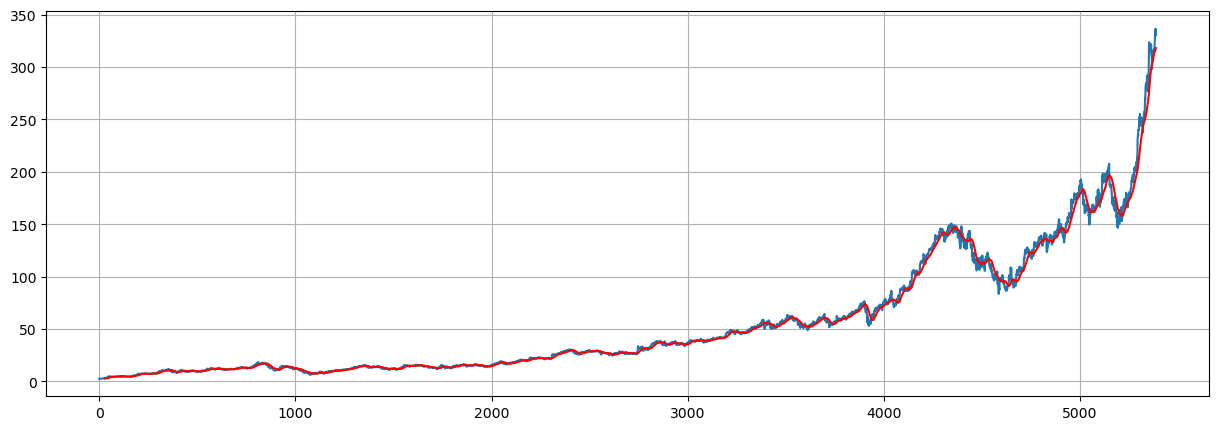

In [ ]:
plt.figure(figsize=(15, 5))
df['Close'].plot()
ma_goog['Close'].plot(color='red')
plt.grid()
plt.show()

In [94]:
train_len = 3770 # Dias de entrenamiento

# Modelo 70 - 30
train = df[0:train_len] # Los primeros 3770 dias para entrenar
test = df[train_len:] # Los ultimos dias para testear el modelo

In [96]:
y_pred_sma = df.copy()
ma_window = 30
y_pred_sma['sma_forecast'] = df['High'].rolling(ma_window).mean()
y_pred_sma['sma_forecast'][train_len] = y_pred_sma['sma_forecast'][train_len -1]

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_25860\1809562012.py:4: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy




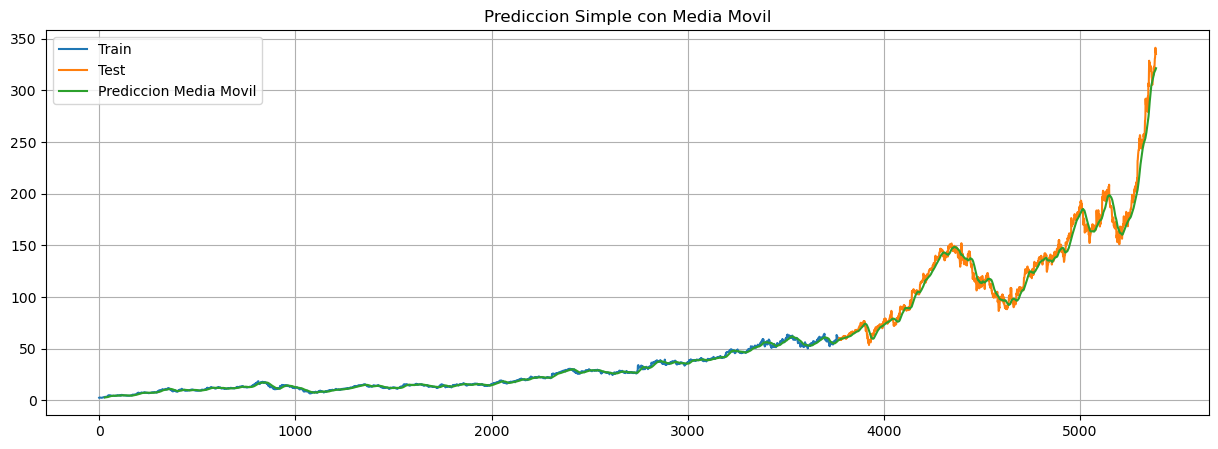

In [97]:
# Grafico de Predicciones
plt.figure(figsize=(15, 5))
plt.grid()
plt.plot(train['High'], label='Train')
plt.plot(test['High'], label='Test')
plt.plot(y_pred_sma['sma_forecast'], label='Prediccion Media Movil')
plt.legend(loc='best')
plt.title('Prediccion Simple con Media Movil')
plt.show()

### Comprobacion de la calidad de las predicciones

In [98]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test['High'], y_pred_sma['sma_forecast'][train_len:])).round(2)
mape = np.round(np.mean(np.abs(test['High'] - y_pred_sma['sma_forecast'][train_len:]) / test['High']) * 100, 2)

results = pd.DataFrame({'Method':['Simple moving acerage forecast'], 'MAPE':[mape], 'RMSE':[rmse]})
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Simple moving acerage forecast,8.27,4.37


In [100]:
# Comparamos lo obtenido con la data real
y_comparation = pd.DataFrame().assign(forecast=y_pred_sma['sma_forecast'])
y_comparation['Observacion'] = df['High']

y_comparation.tail(10)

,forecast,Observacion
5378,317.25,319.25
5379,317.74,321.56
5380,318.49,326.46
5381,318.84,330.54
5382,318.94,331.48
5383,319.25,334.44
5384,319.73,341.20
5385,320.31,337.03
5386,320.96,338.13
5387,321.40,335.24


---

## Visualziacion de Series de Tiempo

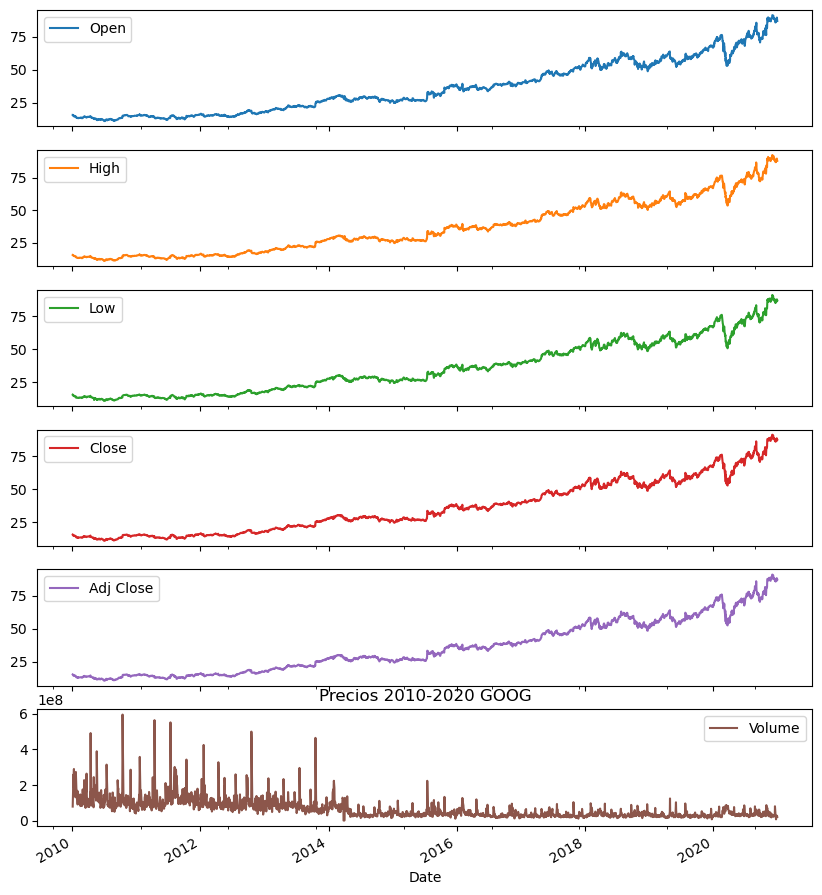

In [83]:
# Convert Date column to datetime and set as index
df_plot = df.copy()
df_plot['Date'] = pd.to_datetime(df_plot['Date'])
df_plot.set_index('Date', inplace=True)

# Plot data for the specified date range
df_plot['2010':'2020'].plot(subplots=True, figsize=(10, 12))
plt.title('Precios 2010-2020 GOOG')
plt.show()